In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
from matplotlib.font_manager import FontProperties
star_font = FontProperties(family='DejaVu Sans')

# Paths
DATA = Path("../data/processed")

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

print("Libraries loaded ✓")

Libraries loaded ✓


In [4]:
stars = pd.read_csv(DATA / "star_ratings.csv")
county = pd.read_csv(DATA / "enrollment_county.csv")
monthly = pd.read_csv(DATA / "enrollment_monthly_state.csv")

print(f"Star ratings:   {stars.shape}")
print(f"County enroll:  {county.shape}")
print(f"Monthly enroll: {monthly.shape}")

Star ratings:   (1602, 9)
County enroll:  (48866, 9)
Monthly enroll: (9860, 8)


## 1. Star Ratings Overview
Exploring the distribution of Medicare Advantage quality ratings across contracts (2024–2026).

In [5]:
stars.head()

,contract_id,plan_name,parent_org,org_type,snp,part_c_stars,part_d_stars,overall_stars,year
0,H0028,Humana,Humana Inc.,Local CCP,Yes,4.0,4.0,4.0,2024
1,H0074,Wellcare,Centene Corporation,Local CCP,Yes,2.5,2.5,2.5,2024
2,H0088,Wellcare,Centene Corporation,Local CCP,No,2.0,2.5,2.0,2024
3,H0104,Blue Cross and Blue Shield of Alabama,BlueCross BlueShield of Alabama,Local CCP,No,4.5,3.5,4.0,2024
4,H0107,Blue Cross and Blue Shield of Montana,Health Care Service Corporation,Local CCP,No,4.0,3.5,3.5,2024


In [6]:
stars.info()

<class 'pandas.DataFrame'>
RangeIndex: 1602 entries, 0 to 1601
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   contract_id    1602 non-null   str    
 1   plan_name      1602 non-null   str    
 2   parent_org     1602 non-null   str    
 3   org_type       1602 non-null   str    
 4   snp            1602 non-null   str    
 5   part_c_stars   1602 non-null   float64
 6   part_d_stars   1582 non-null   float64
 7   overall_stars  1582 non-null   float64
 8   year           1602 non-null   int64  
dtypes: float64(3), int64(1), str(5)
memory usage: 214.2 KB


In [7]:
# Missing values per column
stars.isnull().sum()

contract_id       0
plan_name         0
parent_org        0
org_type          0
snp               0
part_c_stars      0
part_d_stars     20
overall_stars    20
year              0
dtype: int64

**Data quality notes:**
- 1602 contracts × 3 years, no missing values except `part_d_stars` / `overall_stars` (n=20 per year)
- Missing Part D ratings are expected: MA-only contracts don't offer drug coverage
- All star columns correctly typed as float64

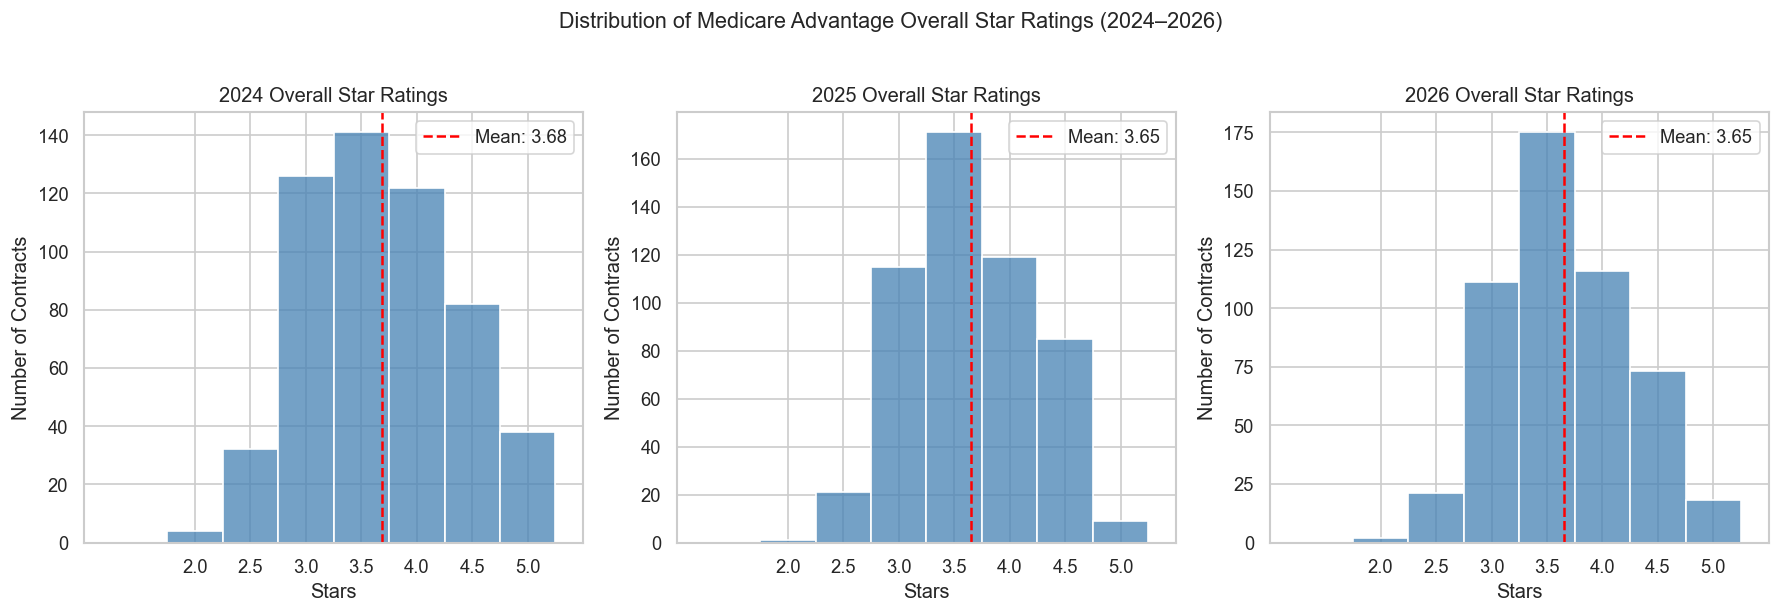

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bins = [1.75, 2.25, 2.75, 3.25, 3.75, 4.25, 4.75, 5.25]  # centered on 0.5 increments

for ax, year in zip(axes, [2024, 2025, 2026]):
    df_year = stars[stars["year"] == year]
    sns.histplot(df_year["overall_stars"].dropna(), bins=bins, ax=ax, color="steelblue")
    ax.set_title(f"{year} Overall Star Ratings")
    ax.set_xlabel("Stars")
    ax.set_ylabel("Number of Contracts")
    ax.set_xlim(1, 5.5)
    ax.set_xticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
    mean = df_year["overall_stars"].mean()
    ax.axvline(mean, color="red", linestyle="--", label=f"Mean: {mean:.2f}")
    ax.legend()

plt.suptitle("Distribution of Medicare Advantage Overall Star Ratings (2024–2026)", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/star_ratings_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** Star ratings are assigned in 0.5 increments (2.0–5.0). 
The mean has been remarkably stable (~3.65) across 2024–2026, suggesting 
the overall quality distribution of MA plans has not changed significantly 
despite year-over-year methodology updates by CMS.

**Observations:**
- 2024 shows a longer tail toward 4.5–5.0 stars compared to 2025 and 2026.
- 2025 and 2026 are more concentrated at 3.5 stars, suggesting CMS tightened 
  its rating methodology or cut points over time.
- Despite the distributional shift, the mean remains remarkably stable (~3.65) 
  across all three years — the overall quality signal has not changed, 
  but fewer contracts are achieving top ratings.
  

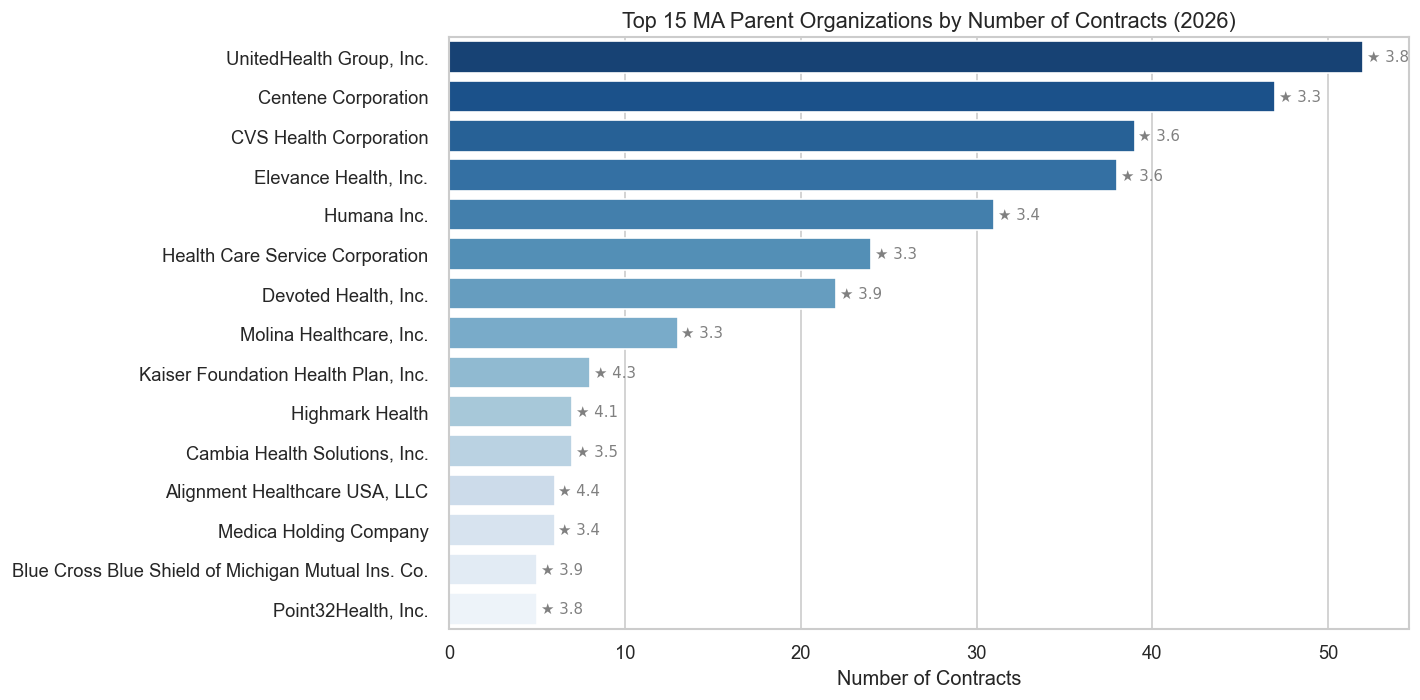

In [18]:
# Top 15 parent organizations by number of contracts (2026)
top_orgs = (stars[stars["year"] == 2026]
            .groupby("parent_org")
            .agg(n_contracts=("contract_id", "count"),
                 avg_stars=("overall_stars", "mean"))
            .sort_values("n_contracts", ascending=False)
            .head(15)
            .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))

bars = sns.barplot(data=top_orgs, y="parent_org", x="n_contracts",
                   hue="parent_org", palette="Blues_r", ax=ax, legend=False)

for i, row in top_orgs.iterrows():
    ax.text(row["n_contracts"] + 0.2, i,
            f'\u2605 {row["avg_stars"]:.1f}', va="center", fontsize=9,
            color="gray", fontproperties=star_font)

ax.set_title("Top 15 MA Parent Organizations by Number of Contracts (2026)", fontsize=13)
ax.set_xlabel("Number of Contracts")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("figures/top_orgs_contracts.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Market Concentration

**Observations:**
- UnitedHealth Group dominates with 50+ contracts, followed by Centene, CVS Health, 
  and Elevance — the top 4 organizations account for the majority of MA contracts.
- Larger organizations tend to have *lower* average star ratings (UnitedHealth ★3.8, 
  Centene ★3.3, Humana ★3.4), while smaller regional players score higher 
  (Kaiser ★4.3, Alignment ★4.4, Highmark ★4.1).
- This quality-scale tradeoff is a known pattern in the MA market: national insurers 
  prioritize geographic reach over quality optimization.

In [21]:
# MA penetration by state (January 2026)
state_pen = (monthly[monthly["YEAR"] == 2026]
             .groupby("BENE_STATE_ABRVTN")
             .agg(total=("TOT_BENES", "sum"),
                  ma=("MA_AND_OTH_BENES", "sum"))
             .assign(ma_penetration=lambda x: x["ma"] / x["total"])
             .sort_values("ma_penetration", ascending=False)
             .reset_index()
             .rename(columns={"BENE_STATE_ABRVTN": "state"}))

exclude = ["PR", "VI", "GU", "MP", "AS", "XX", "ZZ"]
state_pen = state_pen[~state_pen["state"].isin(exclude)]

print(state_pen.head(10))

   state      total         ma  ma_penetration
1     MI  2306545.0  1463027.0        0.634294
2     AL  1137112.0   696312.0        0.612351
3     RI   250243.0   150182.0        0.600145
4     ME   387887.0   227328.0        0.586068
5     NC  2300288.0  1332540.0        0.579293
6     WI  1360081.0   781420.0        0.574539
7     LA   961260.0   551922.0        0.574165
8     FL  5287658.0  3016092.0        0.570402
9     OH  2593199.0  1473245.0        0.568119
10    WV   456267.0   258785.0        0.567179


In [22]:
print(state_pen[state_pen["state"] == "NY"])
print(f"\nNY rank: {state_pen[state_pen['state'] == 'NY'].index[0]} of {len(state_pen)}")

   state      total         ma  ma_penetration
22    NY  4021420.0  2136781.0         0.53135

NY rank: 22 of 53


**Observations:**
- NY ranks 22nd out of 53 with 53% MA penetration — above the national median, 
  with over 2.1 million beneficiaries enrolled in MA out of 4 million total.
- States with the highest penetration (MI 63%, AL 61%) tend to be smaller markets 
  where regional MA plans have historically dominated.
- NY is a large, competitive market with diverse plan options and a high proportion 
  of dual-eligible beneficiaries (Medicare + Medicaid), which can temper MA penetration 
  relative to smaller states.
- Over half of all Medicare beneficiaries nationally are now enrolled in MA — 
  a threshold crossed for the first time in recent years.

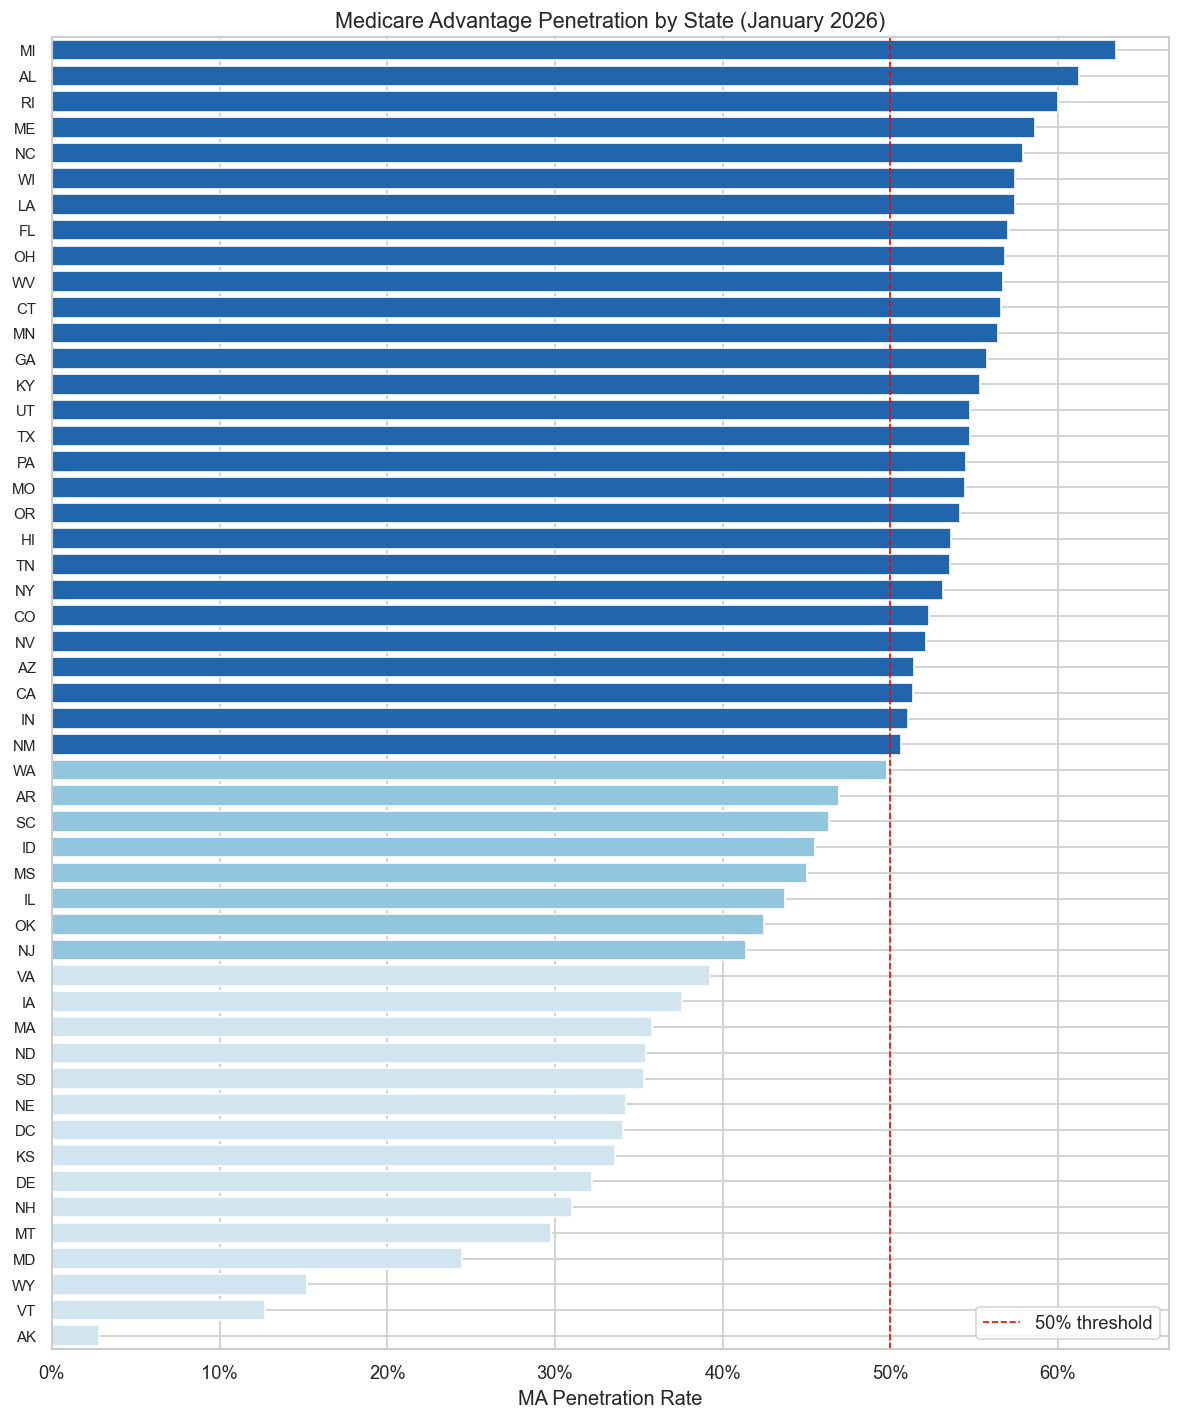

In [29]:
# Remove territories AND unknown AND FO
exclude = ["PR", "VI", "GU", "MP", "AS", "XX", "ZZ", "UK",'FO']
state_pen_clean = state_pen[~state_pen["state"].isin(exclude)]
state_pen_sorted = state_pen_clean.sort_values("ma_penetration", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 12))

colors = ["#2166ac" if x >= 0.5 else "#92c5de" if x >= 0.4 else "#d1e5f0" 
          for x in state_pen_sorted["ma_penetration"]]

# Use plain matplotlib barh instead of seaborn to fix alignment
ax.barh(range(len(state_pen_sorted)), state_pen_sorted["ma_penetration"], color=colors)
ax.set_yticks(range(len(state_pen_sorted)))
ax.set_yticklabels(state_pen_sorted["state"], fontsize=9)

ax.axvline(0.5, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.set_xlabel("MA Penetration Rate")
ax.set_title("Medicare Advantage Penetration by State (January 2026)", fontsize=13)
ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend()
ax.set_ylim(-0.5, len(state_pen_sorted) - 0.5)
plt.tight_layout()
plt.savefig("figures/ma_penetration_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Medicare Advantage Penetration by State (January 2026)

**Observations:**
- 27 out of 51 states/DC have crossed the 50% MA penetration threshold — 
  meaning the majority of Medicare beneficiaries in those states are now in MA plans.
- Michigan leads at 63%, followed by Alabama (61%) and Rhode Island (60%).
- Alaska is the lowest at ~5%, reflecting geographic barriers and limited plan availability 
  in rural and remote areas.
- The Southeast and Midwest show consistently high penetration, while the Northeast 
  and Mountain West remain more mixed.
- NY sits at 53% — above the median despite being one of the largest and most complex 
  Medicare markets in the country, with 2.1M MA enrollees out of 4M total beneficiaries.

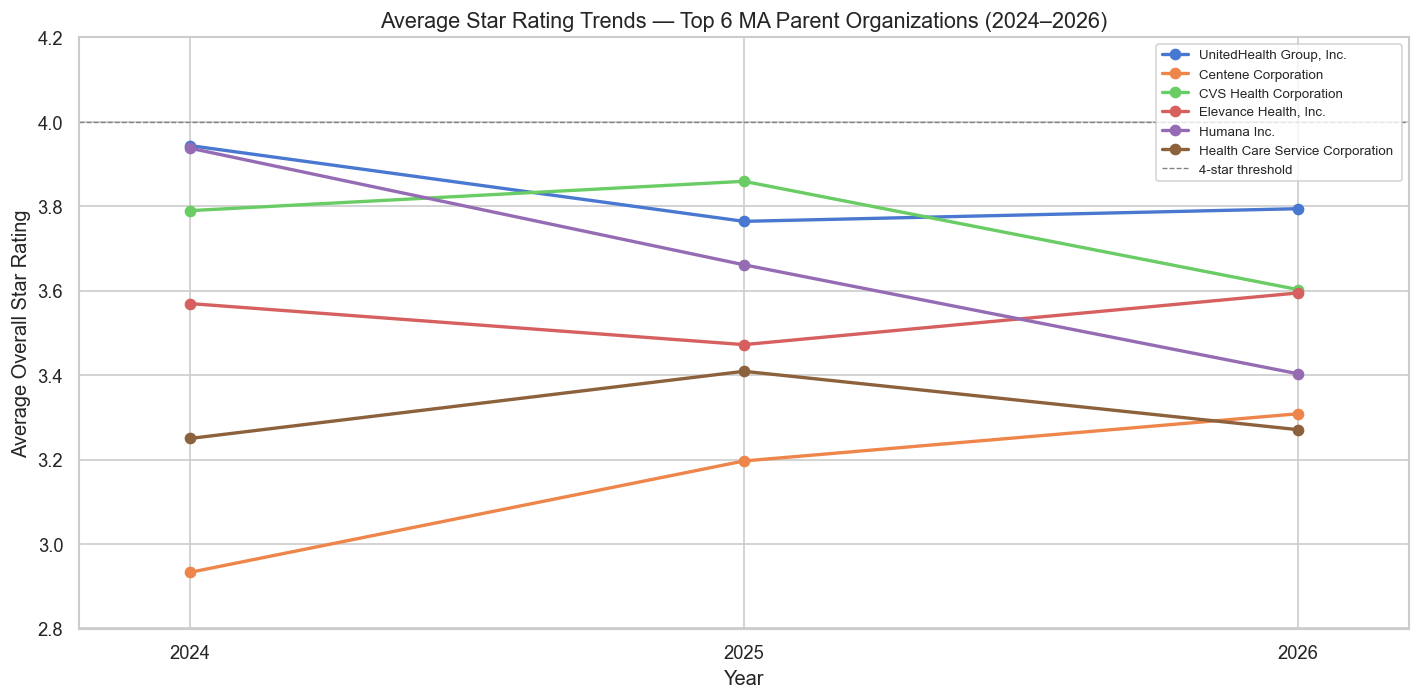

In [34]:
## 4. Star Ratings Trends for Major Insurers (2024–2026)

# Top 6 parent orgs by number of contracts in 2026
top_parents = (stars[stars["year"] == 2026]
               .groupby("parent_org")["contract_id"].count()
               .sort_values(ascending=False)
               .head(6).index.tolist())

# Filter and compute avg overall stars per org per year
trends = (stars[stars["parent_org"].isin(top_parents)]
          .groupby(["parent_org", "year"])["overall_stars"]
          .mean()
          .reset_index())

fig, ax = plt.subplots(figsize=(12, 6))

# Manual y offsets for overlapping labels at 2026
label_offsets = {
    "UnitedHealth Group, Inc.": 8,
    "CVS Health Corporation": 14,
    "Elevance Health, Inc.": -14,
    "Humana Inc.": 8,
    "Centene Corporation": -8,
    "Health Care Service Corporation": -8,
}

for org in top_parents:
    df_org = trends[trends["parent_org"] == org]
    ax.plot(df_org["year"], df_org["overall_stars"],
            marker="o", linewidth=2, label=org)
ax.set_xlim(2023.8, 2026.2)
ax.set_ylim(2.8, 4.2)
ax.set_xticks([2024, 2025, 2026])
ax.set_xlabel("Year")
ax.set_ylabel("Average Overall Star Rating")
ax.set_title("Average Star Rating Trends — Top 6 MA Parent Organizations (2024–2026)", fontsize=13)
ax.axhline(4.0, color="gray", linestyle="--", linewidth=0.8, label="4-star threshold")
ax.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.savefig("figures/star_trends_top_orgs.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Star Rating Trends — Top 6 MA Parent Organizations (2024–2026)

**Observations:**
- No organization has averaged 4+ stars across this period — the 4-star threshold, 
  which triggers quality bonuses from CMS, remains out of reach for the largest players.
- UnitedHealth Group is the most stable, hovering around 3.8 stars across all three years.
- Humana shows the steepest decline (3.95 → 3.4), a notable drop given its scale — 
  this aligns with widely reported CMS payment pressure on Humana in 2025–2026.
- Centene is the only organization trending upward (2.93 → 3.3), though it remains 
  the lowest-rated among the top 6.
- CVS Health (Aetna) shows a sharp decline (3.79 → 3.6), reflecting ongoing integration 
  challenges post-Aetna acquisition.
- All six organizations remain below the 4-star bonus threshold, suggesting that scale 
  and quality are difficult to optimize simultaneously in the MA market.

In [35]:
## 5. Enrollment vs Star Rating — Does Size Predict Quality?

# Aggregate enrollment by contract (April 2026)
enroll_by_contract = (county.groupby("contract_id")["enrolled"]
                      .sum()
                      .reset_index()
                      .rename(columns={"enrolled": "total_enrolled"}))

# Join with 2026 star ratings
stars_2026 = stars[stars["year"] == 2026].copy()
merged = stars_2026.merge(enroll_by_contract, on="contract_id", how="inner")

print(f"Matched contracts: {len(merged)}")
print(merged[["plan_name", "total_enrolled", "overall_stars"]].sort_values("total_enrolled", ascending=False).head(10))

Matched contracts: 0
Empty DataFrame
Columns: [plan_name, total_enrolled, overall_stars]
Index: []


In [36]:
print("Stars contract_id sample:", stars_2026["contract_id"].head(5).tolist())
print("County contract_id sample:", county["contract_id"].head(5).tolist())

Stars contract_id sample: ['H0028 ', 'H0034 ', 'H0074 ', 'H0104 ', 'H0107 ']
County contract_id sample: ['H0104', 'H0154', 'H0432', 'H0710', 'H1889']


In [37]:
stars_2026["contract_id"] = stars_2026["contract_id"].str.strip()

merged = stars_2026.merge(enroll_by_contract, on="contract_id", how="inner")
print(f"Matched contracts: {len(merged)}")
print(merged[["plan_name", "total_enrolled", "overall_stars"]].sort_values("total_enrolled", ascending=False).head(10))

Matched contracts: 512
              plan_name  total_enrolled  overall_stars
289             Humana          2442079            3.5
97    UnitedHealthcare          2252294            4.5
320     Aetna Medicare          1443171            4.5
24   Kaiser Permanente          1369009            4.5
290   UnitedHealthcare          1134089            4.0
417             Humana          1108899            4.5
319     Aetna Medicare          1017864            4.5
48              Humana           826149            4.5
29    UnitedHealthcare           749268            4.5
121   UnitedHealthcare           564999            4.0


In [38]:
print(merged[merged["plan_name"] == "UnitedHealthcare"][
    ["contract_id", "plan_name", "org_type", "snp", "total_enrolled", "overall_stars"]
].sort_values("total_enrolled", ascending=False).head(8))

Empty DataFrame
Columns: [contract_id, plan_name, org_type, snp, total_enrolled, overall_stars]
Index: []


In [39]:
print(merged["plan_name"].head(10).tolist())

['Humana ', 'Hamaspik, Inc. ', 'Wellcare ', 'Blue Cross and Blue Shield of Alabama ', 'Blue Cross and Blue Shield of Montana ', 'Wellcare ', 'VIVA Medicare ', 'UnitedHealthcare ', 'Wellcare ', 'UnitedHealthcare ']


In [40]:
merged["plan_name"] = merged["plan_name"].str.strip()

print(merged[merged["plan_name"] == "UnitedHealthcare"][
    ["contract_id", "plan_name", "org_type", "snp", "total_enrolled", "overall_stars"]
].sort_values("total_enrolled", ascending=False).head(8))

    contract_id         plan_name    org_type   snp  total_enrolled  \
97        H2001  UnitedHealthcare  Local CCP   Yes          2252294   
290       H5253  UnitedHealthcare  Local CCP   Yes          1134089   
29        H0609  UnitedHealthcare  Local CCP   Yes           749268   
121       H2406  UnitedHealthcare  Local CCP   Yes           564999   
144       H2802  UnitedHealthcare  Local CCP   Yes           397393   
49        H1045  UnitedHealthcare  Local CCP   Yes           391964   
453       H8768  UnitedHealthcare  Local CCP    No           311535   
205       H3805  UnitedHealthcare  Local CCP   Yes           282445   

     overall_stars  
97             4.5  
290            4.0  
29             4.5  
121            4.0  
144            4.0  
49             4.5  
453            3.5  
205            3.5  


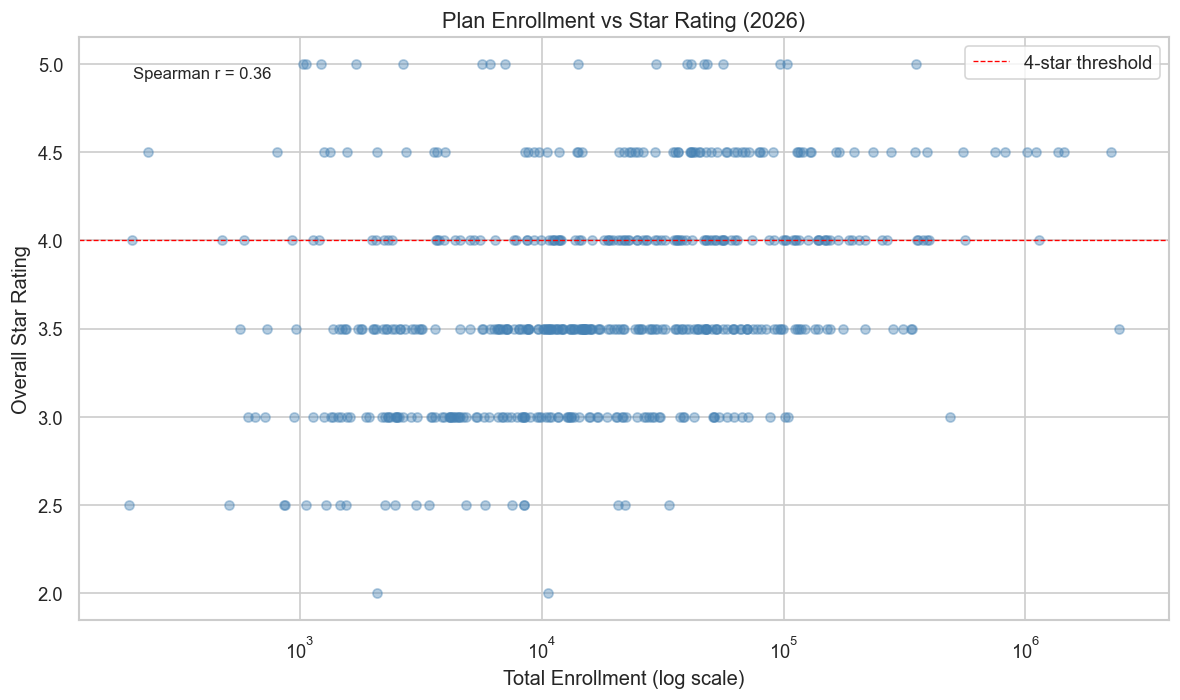

In [42]:

fig, ax = plt.subplots(figsize=(10, 6))

# Log scale for enrollment (very skewed distribution)
ax.scatter(merged["total_enrolled"], merged["overall_stars"],
           alpha=0.4, s=30, color="steelblue")

ax.set_xscale("log")
ax.set_xlabel("Total Enrollment (log scale)")
ax.set_ylabel("Overall Star Rating")
ax.set_title("Plan Enrollment vs Star Rating (2026)", fontsize=13)
ax.set_yticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
ax.axhline(4.0, color="red", linestyle="--", linewidth=0.8, label="4-star threshold")

# Add correlation
corr = merged[["total_enrolled", "overall_stars"]].corr().iloc[0, 1]
ax.text(0.05, 0.95, f"Spearman r = {merged['total_enrolled'].corr(merged['overall_stars'], method='spearman'):.2f}",
        transform=ax.transAxes, fontsize=10, va="top")

ax.legend()
plt.tight_layout()
plt.savefig("figures/enrollment_vs_stars.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Plan Enrollment vs Star Rating (2026)

**Observations:**
- Spearman r = 0.36 — a modest but meaningful positive correlation between 
  enrollment size and star rating.
- Larger plans (>100K enrollees) cluster between 3.5 and 4.5 stars — 
  very few large plans fall below 3.0, suggesting that low-quality plans 
  lose enrollment over time (or exit the market).
- Small plans show the highest variance — they can achieve 5 stars or fall to 2.0. 
  This likely reflects niche regional plans and new entrants still finding their footing.
- The relationship is not causal: size doesn't drive quality, but quality drives retention, 
  which drives size over time.

## 6. SNP vs Non-SNP Star Ratings (2024–2026)

**Background:** Special Needs Plans (SNPs) are Medicare Advantage plans designed 
for high-risk, vulnerable populations:
- **D-SNP** (Dual Eligible): beneficiaries enrolled in both Medicare and Medicaid
- **C-SNP** (Chronic Condition): beneficiaries with specific chronic conditions 
  (e.g., diabetes, heart failure, HIV)
- **I-SNP** (Institutional): beneficiaries residing in long-term care facilities

SNPs face stricter CMS oversight and additional care coordination requirements. 
The question here: do SNPs achieve higher or lower star ratings than standard MA plans?

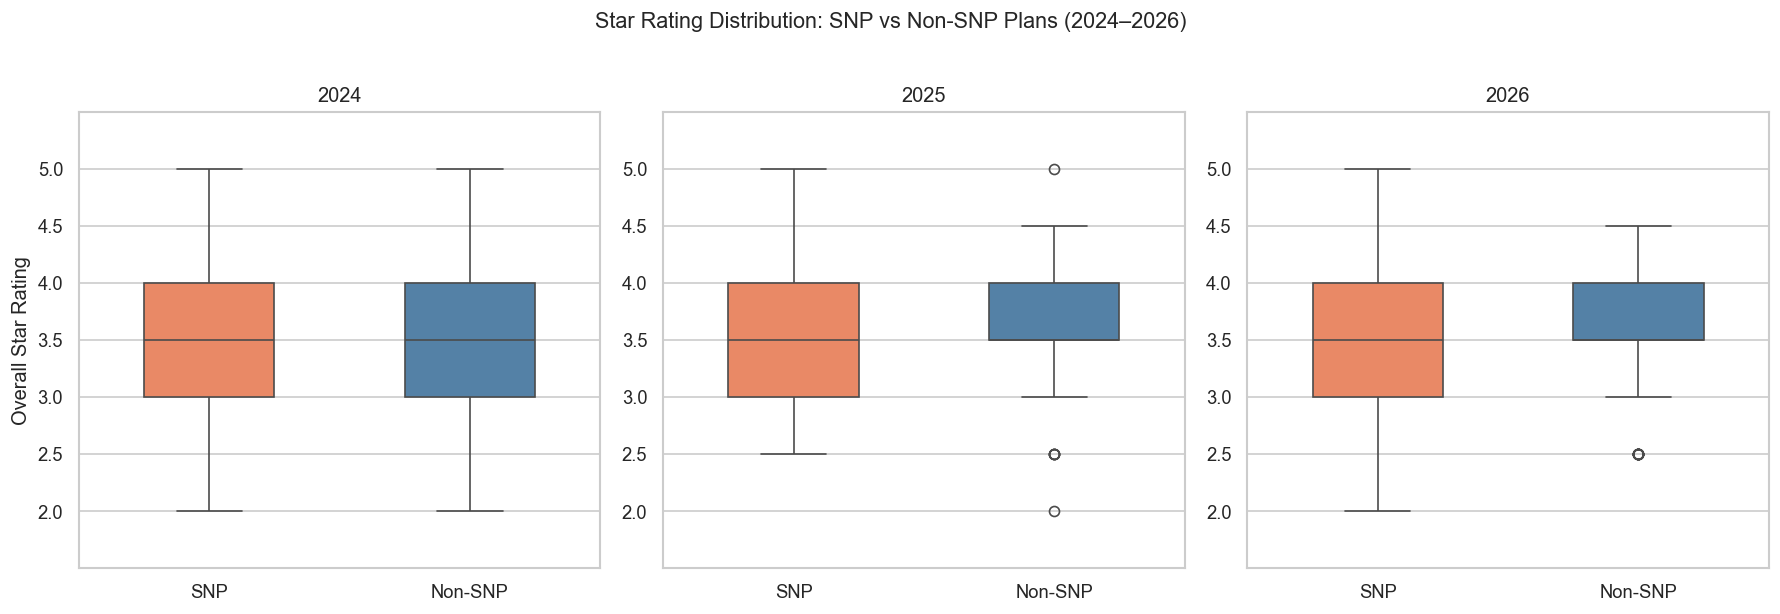

In [45]:
## 6. SNP vs Non-SNP Star Ratings (2024–2026)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, year in zip(axes, [2024, 2025, 2026]):
    df_year = stars[stars["year"] == year].copy()
    df_year["snp"] = df_year["snp"].str.strip()
    df_year["SNP Status"] = df_year["snp"].map({"Yes": "SNP", "No": "Non-SNP"})
    
    sns.boxplot(data=df_year.dropna(subset=["overall_stars"]), 
                x="SNP Status", y="overall_stars",
                hue="SNP Status", palette={"SNP": "coral", "Non-SNP": "steelblue"},
                ax=ax, legend=False, width=0.5)
    
    ax.set_title(f"{year}")
    ax.set_xlabel("")
    ax.set_ylabel("Overall Star Rating" if year == 2024 else "")
    ax.set_ylim(1.5, 5.5)
    ax.set_yticks([2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

plt.suptitle("Star Rating Distribution: SNP vs Non-SNP Plans (2024–2026)", 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/snp_vs_nonsnp_stars.png", dpi=150, bbox_inches="tight")
plt.show()

**Observations:**
- SNP and Non-SNP plans have nearly identical median star ratings (~3.5) across all three years.
- However, Non-SNP plans show a tighter distribution in 2025–2026, with less variance 
  and fewer low-performing outliers — suggesting more consistent quality among standard plans.
- SNP plans have wider variance and more low-performing contracts, consistent with the 
  challenge of serving high-complexity, vulnerable populations under standardized metrics.
- Contrary to what might be expected, SNP designation does not confer a quality advantage 
  despite the additional CMS oversight and care coordination requirements.
- The few outliers below 2.5 stars in Non-SNP plans (2025, 2026) likely represent 
  contracts under CMS scrutiny or on the verge of being terminated.

In [46]:
# Enrollment by SNP status (2026)
merged["snp"] = merged["snp"].str.strip()
snp_enrollment = (merged.groupby("snp")
                  .agg(n_contracts=("contract_id", "count"),
                       total_enrolled=("total_enrolled", "sum"),
                       avg_stars=("overall_stars", "mean"),
                       median_stars=("overall_stars", "median"))
                  .reset_index())

print(snp_enrollment)
print(f"\nAvg enrollment per SNP contract:     {snp_enrollment[snp_enrollment['snp']=='Yes']['total_enrolled'].values[0] / snp_enrollment[snp_enrollment['snp']=='Yes']['n_contracts'].values[0]:,.0f}")
print(f"Avg enrollment per Non-SNP contract: {snp_enrollment[snp_enrollment['snp']=='No']['total_enrolled'].values[0] / snp_enrollment[snp_enrollment['snp']=='No']['n_contracts'].values[0]:,.0f}")

   snp  n_contracts  total_enrolled  avg_stars  median_stars
0   No          207         9717720   3.649254           3.5
1  Yes          305        25048273   3.660656           3.5

Avg enrollment per SNP contract:     82,125
Avg enrollment per Non-SNP contract: 46,946


**Enrollment-weighted check:**
- SNP contracts are on average nearly twice as large as Non-SNP contracts 
  (82K vs 47K enrollees per contract), yet their average star ratings are 
  virtually identical (3.66 vs 3.65).
- This confirms the boxplot comparison is valid: the similar quality distributions 
  are not an artifact of sample size differences.
- The higher average enrollment in SNP plans likely reflects the D-SNP segment, 
  where large insurers (UnitedHealth, Humana) dominate by serving dual-eligible 
  populations at scale.

In [47]:
# What SNP types exist in the data?
print(stars[stars["year"] == 2026]["snp"].str.strip().value_counts())

snp
Yes    307
No     217
Name: count, dtype: int64
